# Importing the dataset

In [2]:
import pandas as pd
import numpy as np

filepath = r"https://raw.githubusercontent.com/UlvenRev/Dropout-and-Burnout-Prediction-with-Logistic-Regression/refs/heads/main/Burnout%20%26%20Dropout%20Predictions/student_burnout_dropout_dataset_2.csv"
student_data = pd.read_csv(filepath, index_col="Student_ID")

student_data.head()

,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Sleep_Hours,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
Student_ID,,,,,,,,,,,,,,,,,,,,,
STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,6.2,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,NaN,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,4.2,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,5.7,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,8.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


In [2]:
# Making a copy of the dataset with which we will work:
student_data_copy = student_data.copy()

___
# Custom functions

3 functions for:
1. Preprocessing 
2. Training the model and getting predictions
3. Drawing the SHAP plot

In [3]:
from sklearn.model_selection import train_test_split 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

def preprocess(df, target_col: str, other_target_cols: list = None, low_impact_cols: list = None):
    # 1) Choose target and features 
    y = df[target_col]

    if other_target_cols is not None and low_impact_cols is not None:  # If have any other targets or low impact columns to EXCLUDE
        X = df.drop(columns=[target_col] + other_target_cols + low_impact_cols)
    elif other_target_cols is not None and low_impact_cols is None:  # Only other targets to exclude
        X = df.drop(columns=[target_col] + other_target_cols)
    elif other_target_cols is None and low_impact_cols is not None:  # Only low impact columns to exclude
        X = df.drop(columns=[target_col] + low_impact_cols)
    else:  # Exclude only the current target
        X = df.drop(columns=[target_col])

    # 2) Split
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=0)

    # 3) Deal with missing values 
    cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]
    numerical_imputer = SimpleImputer()

    for col in cols_with_missing:
        if col in ["Gender", "Department", "Residence_Type"]:  # For all of these insert "Other" for NaN
            X_train[col] = X_train[col].fillna("Other")
            X_valid[col] = X_valid[col].fillna("Other")
        elif col == "Part_Time_Job":  # "No" for NaN
            X_train[col] = X_train[col].fillna("No")
            X_valid[col] = X_valid[col].fillna("No")
        elif col == "Family_Income_Bracket":  # Most frequent value for NaN
            income_bracket_imputer = SimpleImputer(strategy="most_frequent")
            X_train[col] = income_bracket_imputer.fit_transform(X_train[[col]]).ravel()
            X_valid[col] = income_bracket_imputer.transform(X_valid[[col]]).ravel()
        else:  # Impute numerically (imputer decides how)
            X_train[col] = numerical_imputer.fit_transform(X_train[[col]]).ravel()
            X_valid[col] = numerical_imputer.transform(X_valid[[col]]).ravel()

    # 4) Encode categorical variables
    encoders = {}  # To return and use later outside this function

    categorical_cols = [col for col in X_train.columns if X_train[col].dtype == "str" or X_train[col].dtype == "object"]
    ordinal_encoder = OrdinalEncoder()
    OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    for col in categorical_cols:
        # Ordinal Encoding: Encoding as binary, no additional columns added
        if col in ["Gender", "Part_Time_Job", "Family_Income_Bracket", "Counseling_Access"]:  
            if col != "Family_Income_Bracket":
                X_train[col] = ordinal_encoder.fit_transform(X_train[[col]]).ravel()
                X_valid[col] = ordinal_encoder.transform(X_valid[[col]]).ravel()
                encoders["ordinal_encoder"] = ordinal_encoder
            else:
                bracket_encoder = OrdinalEncoder(categories=[["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"]])
                X_train[col] = bracket_encoder.fit_transform(X_train[[col]]).ravel()
                X_valid[col] = bracket_encoder.transform(X_valid[[col]]).ravel()
                encoders["bracket_encoder"] = bracket_encoder
        # One-Hot Encoding: Adding additional columns to mark presence and absence
        else: 
            OH_cols_train = pd.DataFrame(
                                OH_encoder.fit_transform(X_train[[col]]), 
                                columns=OH_encoder.get_feature_names_out([col])
                            )
            OH_cols_valid = pd.DataFrame(
                                OH_encoder.transform(X_valid[[col]]), 
                                columns=OH_encoder.get_feature_names_out([col])
                            )
            OH_cols_train.index = X_train.index
            OH_cols_valid.index = X_valid.index

            removed_col_X_train = X_train.drop(columns=[col])
            removed_col_X_valid = X_valid.drop(columns=[col])

            X_train = pd.concat([removed_col_X_train, OH_cols_train], axis=1)
            X_valid = pd.concat([removed_col_X_valid, OH_cols_valid], axis=1)

            X_train.columns = X_train.columns.astype(str)
            X_valid.columns = X_valid.columns.astype(str)

            encoders["one_hot"] = OH_encoder

    # 5) Return what's needed for training and predicting
    return X_train, X_valid, y_train, y_valid, encoders

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

def get_model_predictions(X_train, X_valid, y_train, y_valid, *, multiclass = False):
    print("[Training a model...]\n")

    # 1) Create a param_grid with parameters for the model you want to check
    param_grid = {
        "C": [0.001, 0.01, 0.1, 1, 10, 100]  # The only parameter I want to check
    }

    # 2) Run GridSearchCV to choose the best parameters
    if not multiclass:
        grid_search = GridSearchCV(
            LogisticRegression(max_iter=2000),
            param_grid,
            cv=5,
            scoring="roc_auc"
        )
    else: 
        grid_search = GridSearchCV(
            LogisticRegression(max_iter=6000),
            param_grid,
            cv=5,
            scoring="roc_auc_ovr"
        )

    grid_search.fit(X_train, y_train)  # Actually runs the grid search and train separate LR models
    best_model = grid_search.best_estimator_
    print(f"Parameters chosen: {grid_search.best_params_}")
    print(f"Model's AUC: {grid_search.best_score_}")

    # 3.5) Actual model's performance on unseen data, not only on training data
    probs = best_model.predict_proba(X_valid)
    valid_auc = roc_auc_score(y_valid, probs[:, 1] if not multiclass else probs, multi_class="ovr" if multiclass else "raise")
    print(f"Validation AUC: {valid_auc}")

    # 3) Make predictions
    predictions = best_model.predict(X_valid)
    print("\nPredictions made and returned!\n")

    return best_model, predictions

In [5]:
import shap

def shap_visualization(best_model, X_train, X_valid, *, multiclass = False):
    explainer = shap.LinearExplainer(best_model, shap.sample(X_train, 100))  # Taking a sample of 100 sample since SHAP doesn't compute more than this anyway 
    shap_values = explainer(X_valid)

    print("[Plotting a SHAP values graph...]")
    if not multiclass:
        shap.plots.beeswarm(shap_values, max_display=X_train.shape[1])
    else: 
        class_names = best_model.classes_
        for i, class_name in enumerate(class_names):
            print(f"SHAP summary for class: {class_name}")
            shap.plots.beeswarm(shap_values[:, :, i], max_display=X_train.shape[1])  # For multiclass, SHAP values have shape (n_samples, n_features, n_classes)

___
# Training the model for predicting `Dropout_Risk`

Since we already know from the previous files which features to **leave out**, I'm going to train the model straight away on the **reduced set of features**:

[Training a model...]

Parameters chosen: {'C': 10}
Model's AUC: 0.7733167301448551
Validation AUC: 0.8041908249415115

Predictions made and returned!

[Plotting a SHAP values graph...]


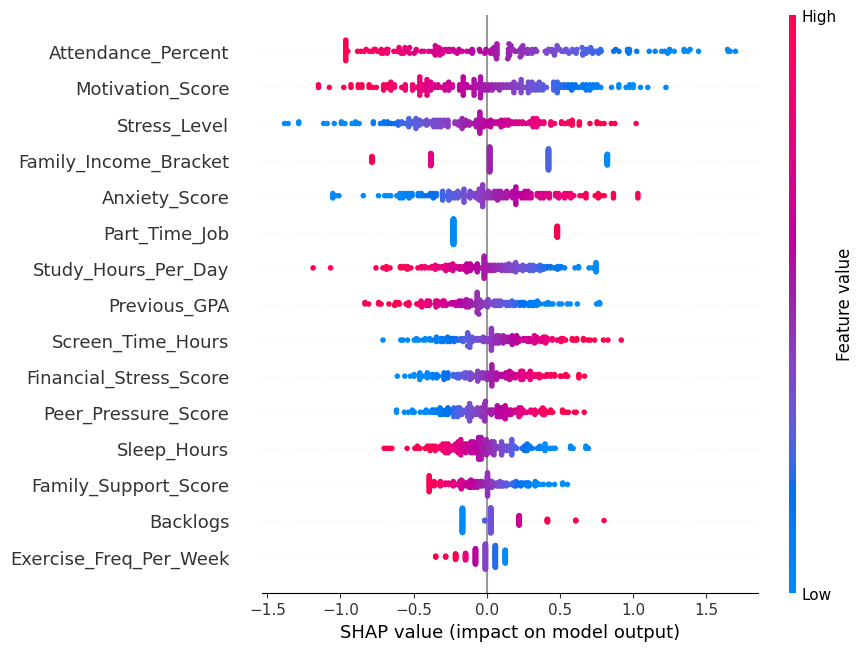

In [6]:
low_impact_cols_DR = ['Gender', 'Counseling_Access', 'Age', 'Year_of_Study', 'Social_Activity_Score', 'Department', 'Residence_Type']
X_train_DR, X_valid_DR, y_train_DR, y_valid_DR, encoders_DR = preprocess(student_data_copy, "Dropout_Risk", ["Burnout_Level"], low_impact_cols_DR)
model_DR, preds_DR = get_model_predictions(X_train_DR, X_valid_DR, y_train_DR, y_valid_DR)
shap_visualization(model_DR, X_train_DR, X_valid_DR)

Keeping the good model:

In [7]:
prediction_model_DR = model_DR

___
# Training the model for predicting `Burnout_Level`

Same thing here - from previous files I know which features I don't need, so I don't include them and do only one single run for training the model:

[Training a model...]

Parameters chosen: {'C': 100}
Model's AUC: 0.8718735430734942
Validation AUC: 0.8749760018166546

Predictions made and returned!

[Plotting a SHAP values graph...]
SHAP summary for class: High


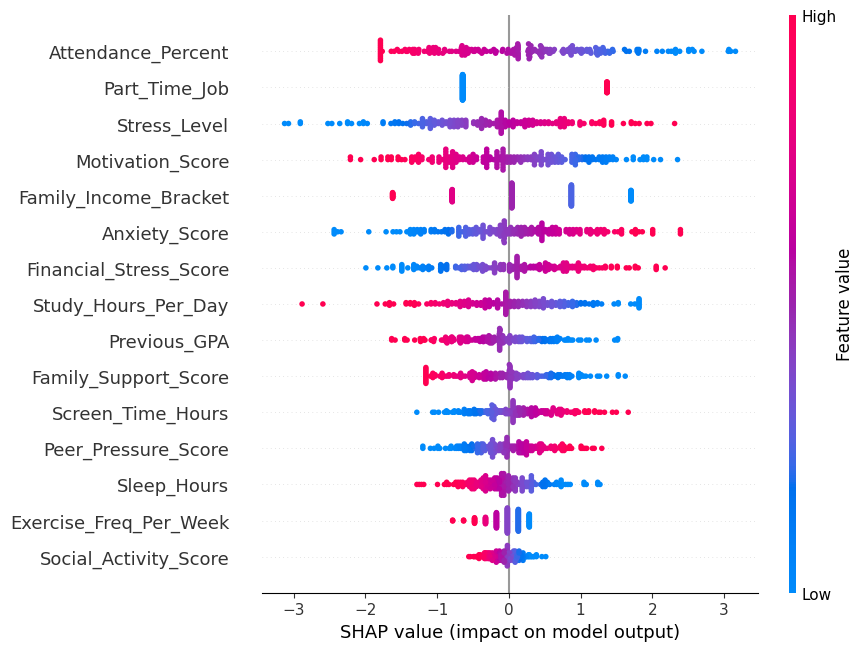

SHAP summary for class: Low


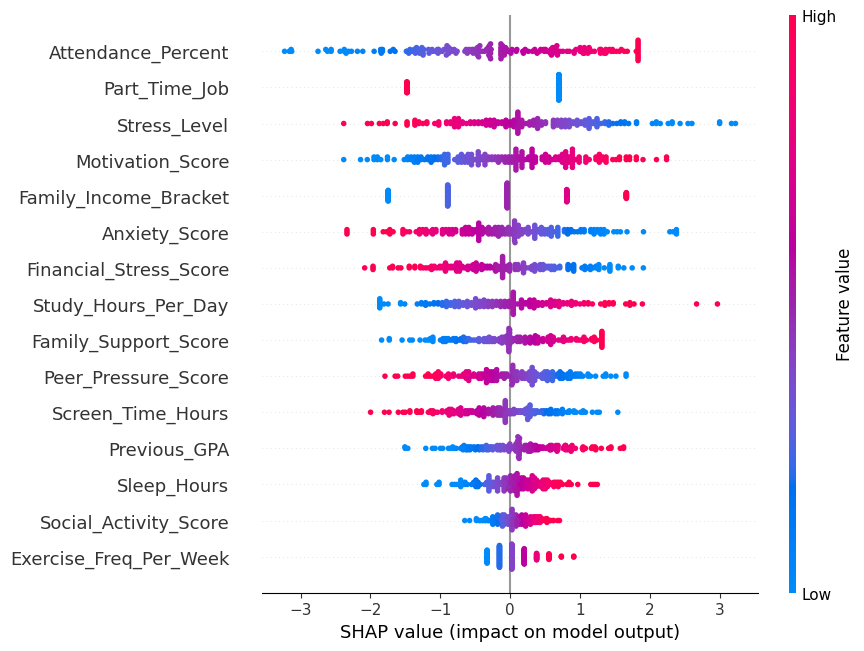

SHAP summary for class: Medium


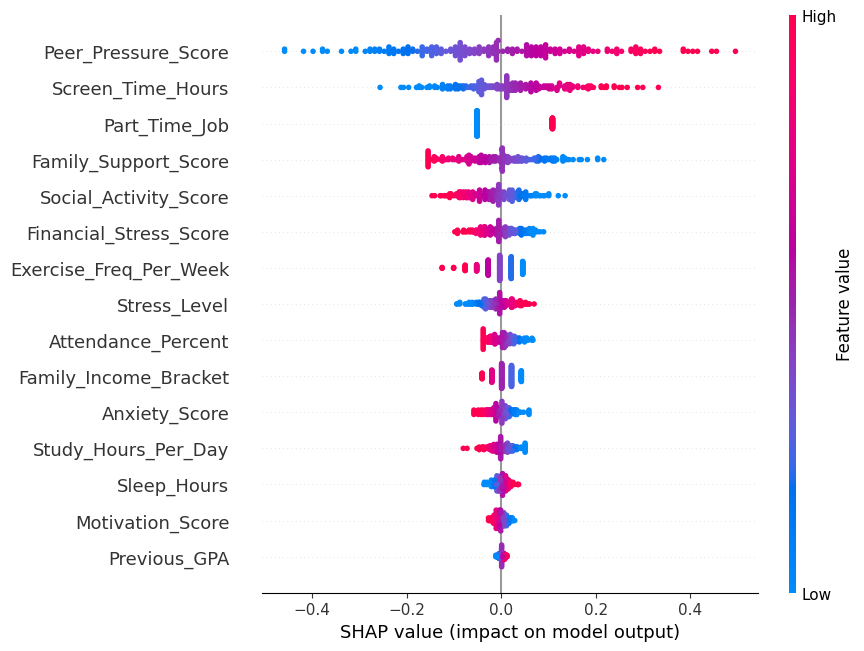

In [8]:
low_impact_cols_BL = ['Counseling_Access', 'Department', 'Residence_Type', 'Age', 'Gender', 'Backlogs', 'Year_of_Study']
X_train_BL, X_valid_BL, y_train_BL, y_valid_BL, encoders_BL = preprocess(student_data_copy, "Burnout_Level", ["Dropout_Risk"], low_impact_cols_BL)
model_BL, preds_BL = get_model_predictions(X_train_BL, X_valid_BL, y_train_BL, y_valid_BL, multiclass=True)
shap_visualization(model_BL, X_train_BL, X_valid_BL, multiclass=True)

Keeping the good model:

In [9]:
prediction_model_BL = model_BL

___
# Test the model with your own data entry!

I made a small custom function which will accept your data entry and return the predicted answer:

In [10]:
def make_prediction(model, data, encoders):
    data_copy = data.copy()
    data_copy["Part_Time_Job"] = encoders["ordinal_encoder"].transform(data_copy[["Part_Time_Job"]]).ravel()
    data_copy["Family_Income_Bracket"] = encoders["bracket_encoder"].transform(data_copy[["Family_Income_Bracket"]]).ravel()
    
    prediction_answer = model.predict(data_copy)

    return prediction_answer

### Predicting `Dropout_Risk`

Use **this** data below to predict `Dropout_Risk` by inserting your own parameters into `[]`: (commented values are **allowed ranges**)

In [11]:
data_for_DR = pd.DataFrame({
    "Attendance_Percent": [70],              # 0.0 - 100.0
    "Study_Hours_Per_Day": [3],              # 0.0 - 24.0
    "Previous_GPA": [9.1],                   # 0.0 - 10.0 (like 0% - 100%)
    "Backlogs": [0],                         # min is 0
    "Sleep_Hours": [8],                      # 0.0 - 24.0
    "Screen_Time_Hours": [5],                # 0.0 - 24.0
    "Exercise_Freq_Per_Week": [3],           # 0 - 7
    "Part_Time_Job": ["No"],                 # Yes/No
    "Family_Income_Bracket": ["Middle"],     # Low, Lower-Middle, Middle, Upper-Middle, High
    "Financial_Stress_Score": [1.4],         # 0.0 - 10.0
    "Family_Support_Score": [6.1],           # 0.0 - 10.0
    "Stress_Level": [3],                     # 0.0 - 10.0
    "Anxiety_Score": [1],                    # 0.0 - 10.0
    "Motivation_Score": [5],                 # 0.0 - 10.0
    "Peer_Pressure_Score": [3]               # 0.0 - 10.0
})

Once you've inserted desired parameters above, run the code cell below to get your prediction:

In [12]:
predict_DR = make_prediction(prediction_model_DR, data_for_DR, encoders_DR)
print(predict_DR)

['No']


### Predicting `Burnout_Level`

Same thing - use the code cell **below** to enter your desired parameters:

In [13]:
data_for_BL = pd.DataFrame({
    "Attendance_Percent": [30],              # 0.0 - 100.0
    "Study_Hours_Per_Day": [6],              # 0.0 - 24.0
    "Previous_GPA": [9.8],                   # 0.0 - 10.0 (like 0% - 100%)
    "Sleep_Hours": [4],                      # 0.0 - 24.0
    "Screen_Time_Hours": [3],                # 0.0 - 24.0
    "Exercise_Freq_Per_Week": [6],           # 0 - 7
    "Social_Activity_Score": [2],            # 0.0 - 10.-
    "Part_Time_Job": ["Yes"],                # Yes/No
    "Family_Income_Bracket": ["Middle"],     # Low, Lower-Middle, Middle, Upper-Middle, High
    "Financial_Stress_Score": [5],           # 0.0 - 10.0
    "Family_Support_Score": [5],             # 0.0 - 10.0
    "Stress_Level": [5],                     # 0.0 - 10.0
    "Anxiety_Score": [4],                    # 0.0 - 10.0
    "Motivation_Score": [3],                 # 0.0 - 10.0
    "Peer_Pressure_Score": [3]               # 0.0 - 10.0
})

Run the code cell below to get your prediction:

In [14]:
predict_BL = make_prediction(prediction_model_BL, data_for_BL, encoders_BL)
print(predict_BL)

['High']
